In [37]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 



import warnings 


warnings.filterwarnings("ignore")

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
## checking basic info 

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
## checking for null value 

df.isna().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
### percentage of missing value 

(df.isna().sum() / len(df))*100


survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

##### For age we can fill it with the median as median is more robust to outliers 
##### For embarked , embark_town  we can fill it with mode 
##### For deck we have to drop it 

In [6]:
## dropping deck col 

df = df.drop(['deck'] , axis=1)


In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


<Axes: ylabel='Density'>

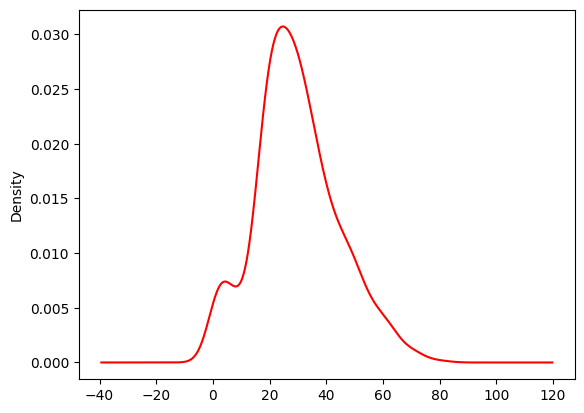

In [8]:
## normal distribution curve for age 

df['age'].plot(kind = 'kde' , c = 'r')


In [9]:
## filling missing value in age col 

df['age'] = df['age'].fillna(df['age'].median())


<Axes: ylabel='Density'>

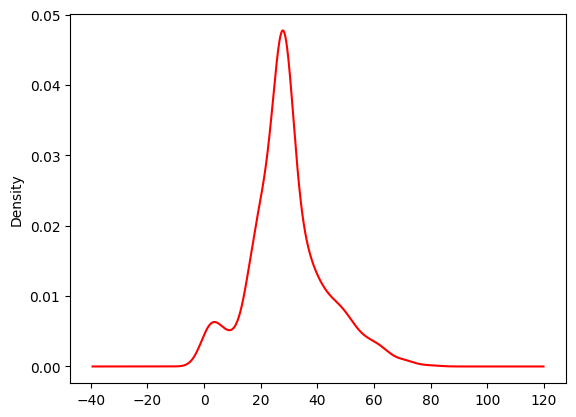

In [10]:
df['age'].plot(kind = 'kde' , c = 'r')

In [11]:
## filling missing value in embarked , embark_town 


for i in df[['embarked' , 'embark_town']]: 
   df[i] = df[i].fillna(df[i].mode()[0])


In [12]:
## checking for null value 

df.isna().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [13]:
## EDA


num_col = df.select_dtypes(include='number')

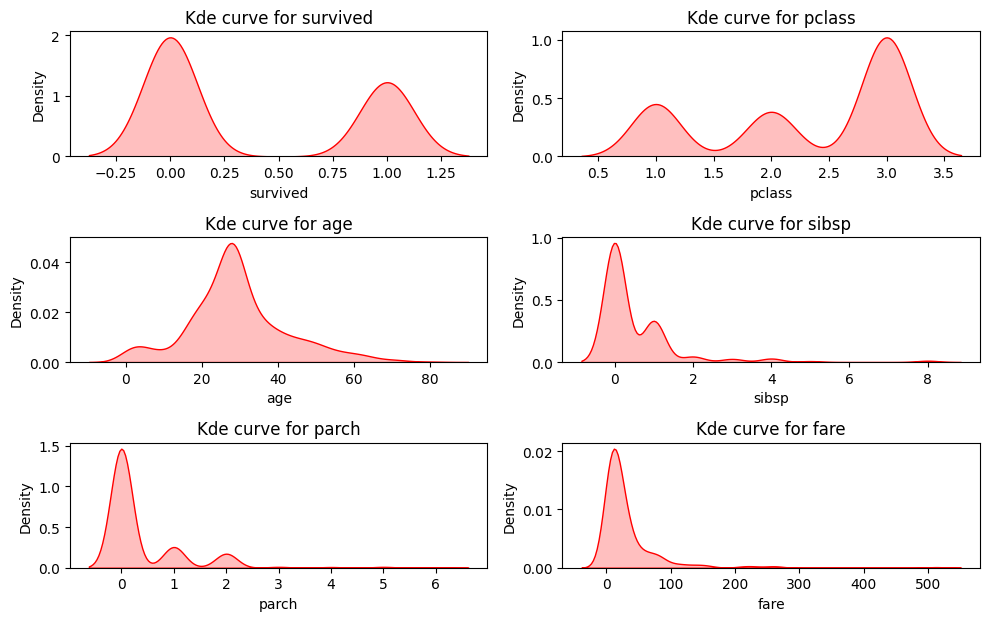

In [14]:
## priting kde curve 

plt.figure(figsize=(10,10))

for i , col in enumerate(num_col):
    plt.subplot(5,2 , i+1) 
    plt.title(f"Kde curve for {col}")
    sns.kdeplot(num_col[col] , fill=True , color  = 'r')

plt.tight_layout()
plt.show()
    

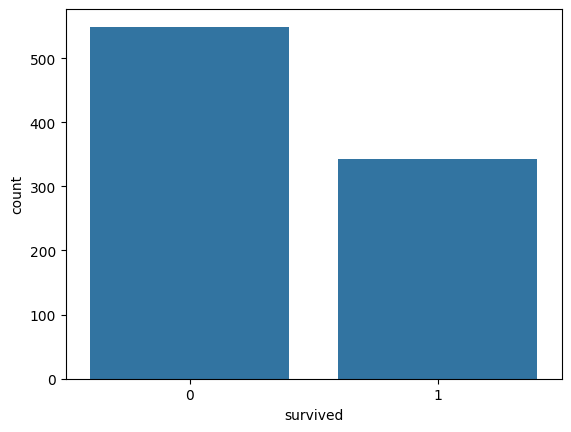

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [15]:
sns.countplot(data=df, x='survived')
plt.show()

df['survived'].value_counts(normalize=True) * 100

##### Observation: The target variable is moderately imbalanced. Approximately 61.6% of passengers did not survive, while 38.4% survived. Since the imbalance is not extreme, standard classification algorithms can be used without applying class balancing techniques.

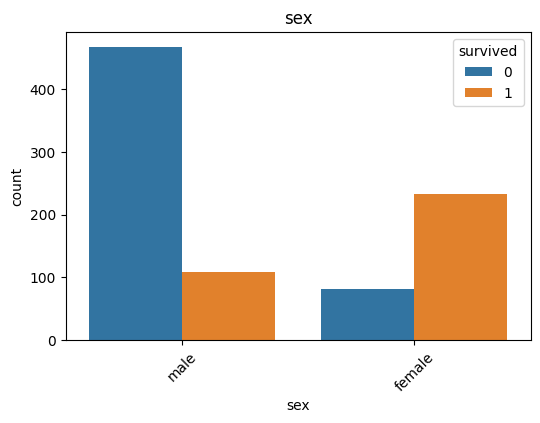

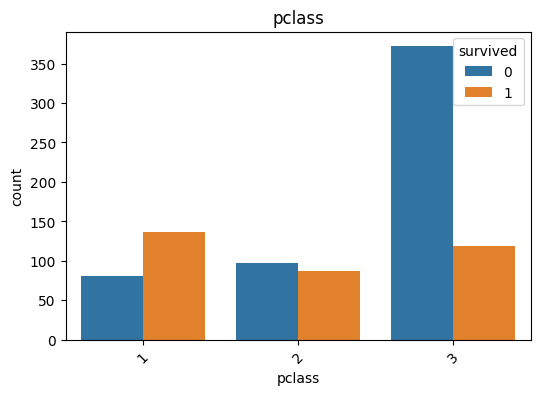

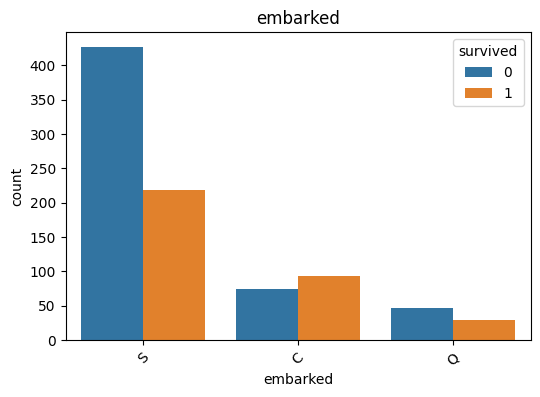

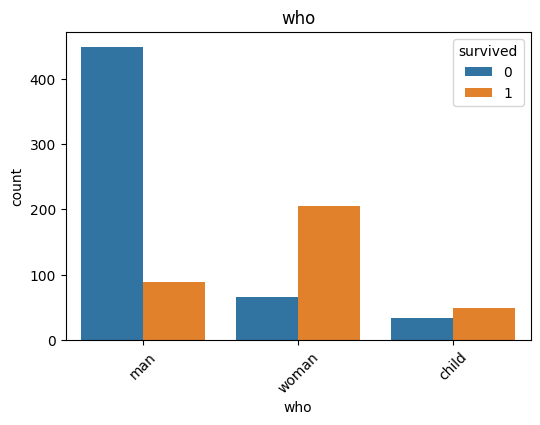

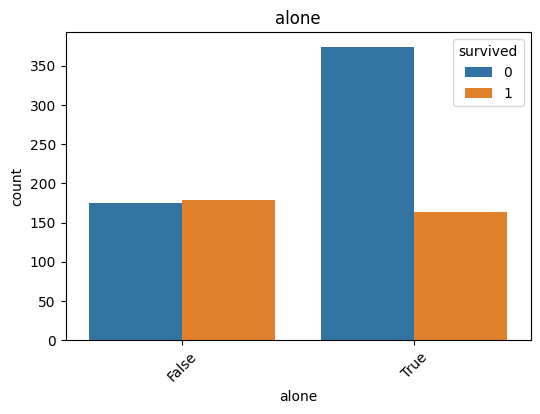

In [16]:
cat_cols = ['sex', 'pclass', 'embarked', 'who', 'alone']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='survived')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

###### Female passengers had a much higher survival rate than male passengers.
###### First-class passengers (pclass = 1) had the highest number of survivors. In fact, more passengers survived than died in this class.
###### Second-class passengers (pclass = 2) had a relatively balanced outcome, with slightly more non-survivors than survivors.
###### Third-class passengers (pclass = 3) had the highest number of deaths. The majority of third-class passengers did not survive.

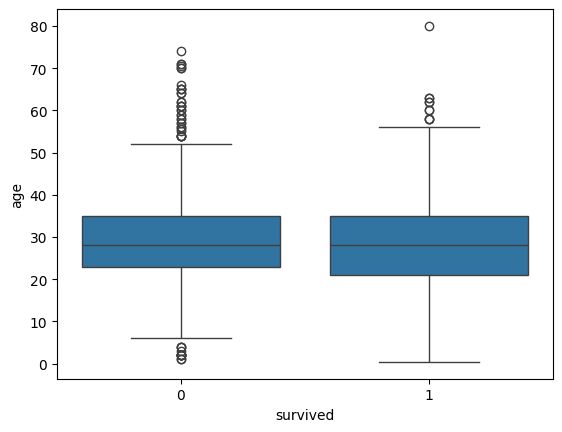

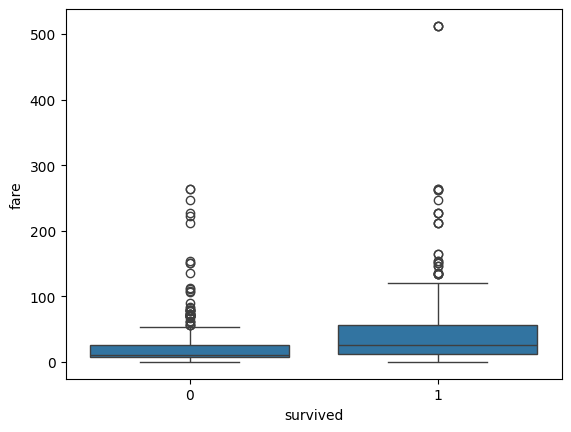

In [17]:
sns.boxplot(data=df, x='survived', y='age')
plt.show()

sns.boxplot(data=df, x='survived', y='fare')
plt.show()

In [18]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


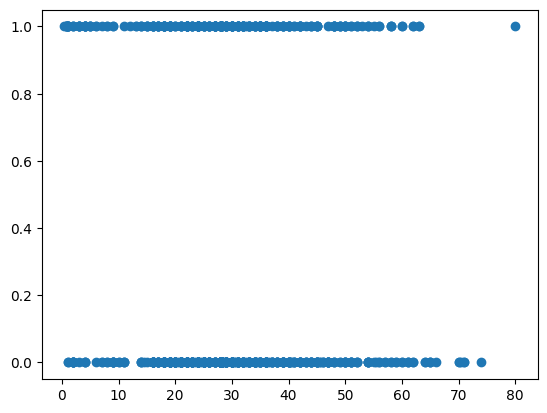

In [19]:
## scatter plot  

plt.scatter(x = 'age' , y = 'survived' , data = df)


In [20]:
## removing unnecessary col class , who , alive  , embark_town , adult_male 

df.drop(['class' , 'who' , 'alive' , 'embark_town' , 'adult_male'] , inplace=True , axis=1)


In [21]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [22]:
# getDummies 

dummy_Df = pd.get_dummies(df[['sex', 'embarked']] , dtype=int , drop_first=True)



In [23]:
df = pd.concat([df , dummy_Df] , axis=1)

In [24]:
## changing alone col 
## true ==1 false = 0

df['alone'] = np.where(df['alone'] == False, 0, 1)


In [25]:
## removing sex , embarked 

df.drop(['sex' , 'embarked'],axis = 1 , inplace=True)


In [26]:
df.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,0,1
4,0,3,35.0,0,0,8.0500,1,1,0,1


In [27]:
## independent and dependent feature 

X = df.drop(['survived'] , axis=1)
y = df['survived']

In [28]:
## data splitting 

from sklearn.model_selection import train_test_split 

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2  , random_state=42)


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def prediction(actual, predicted):
    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)
    roc_auc = roc_auc_score(actual, predicted)

    return accuracy, precision, recall, f1, roc_auc

In [33]:
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB 
from xgboost import XGBClassifier 
from sklearn.ensemble import GradientBoostingClassifier , AdaBoostClassifier , RandomForestClassifier

In [38]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "XGBoost": XGBClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier() ,
    'Random Forest':RandomForestClassifier()
}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("=" * 50)
    print(model_name)

    train_metrics = prediction(y_train, y_train_pred)
    test_metrics = prediction(y_test, y_test_pred)

    print("Training Performance")
    print(f"Accuracy : {train_metrics[0]:.4f}")
    print(f"Precision: {train_metrics[1]:.4f}")
    print(f"Recall   : {train_metrics[2]:.4f}")
    print(f"F1 Score : {train_metrics[3]:.4f}")
    print(f"ROC AUC  : {train_metrics[4]:.4f}")

    print("\nTesting Performance")
    print(f"Accuracy : {test_metrics[0]:.4f}")
    print(f"Precision: {test_metrics[1]:.4f}")
    print(f"Recall   : {test_metrics[2]:.4f}")
    print(f"F1 Score : {test_metrics[3]:.4f}")
    print(f"ROC AUC  : {test_metrics[4]:.4f}")

Logistic Regression
Training Performance
Accuracy : 0.8034
Precision: 0.7645
Recall   : 0.6903
F1 Score : 0.7255
ROC AUC  : 0.7810

Testing Performance
Accuracy : 0.8045
Precision: 0.7826
Recall   : 0.7297
F1 Score : 0.7552
ROC AUC  : 0.7934
Decision Tree
Training Performance
Accuracy : 0.9789
Precision: 0.9961
Recall   : 0.9478
F1 Score : 0.9713
ROC AUC  : 0.9728

Testing Performance
Accuracy : 0.8045
Precision: 0.7600
Recall   : 0.7703
F1 Score : 0.7651
ROC AUC  : 0.7994
KNN
Training Performance
Accuracy : 0.7893
Precision: 0.7458
Recall   : 0.6679
F1 Score : 0.7047
ROC AUC  : 0.7653

Testing Performance
Accuracy : 0.7039
Precision: 0.6842
Recall   : 0.5270
F1 Score : 0.5954
ROC AUC  : 0.6778
Gaussian NB
Training Performance
Accuracy : 0.7992
Precision: 0.7376
Recall   : 0.7239
F1 Score : 0.7307
ROC AUC  : 0.7842

Testing Performance
Accuracy : 0.7765
Precision: 0.7297
Recall   : 0.7297
F1 Score : 0.7297
ROC AUC  : 0.7696
XGBoost
Training Performance
Accuracy : 0.9649
Precision: 0.97

In [40]:
## HyperParameter Tuning 

from scipy.stats import randint, uniform

param_dist = {
    "Logistic Regression": {
        "C": uniform(0.01, 10),
        "penalty": ["l1", "l2"],
        "solver": ["liblinear", "saga"],
        "max_iter": [500, 1000, 2000]
    },

    "Decision Tree": {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": randint(2, 20),
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 10),
        "max_features": ["sqrt", "log2", None]
    },

    "KNN": {
        "n_neighbors": randint(3, 25),
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan", "minkowski"],
        "p": [1, 2]
    },

    "Gaussian NB": {
        "var_smoothing": uniform(1e-11, 1e-8)
    },

    "XGBoost": {
        "n_estimators": randint(100, 500),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": randint(3, 10),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "gamma": uniform(0, 5)
    },

    "Gradient Boosting": {
        "n_estimators": randint(50, 300),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": randint(2, 10),
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 10),
        "subsample": uniform(0.6, 0.4)
    },

    "AdaBoost": {
        "n_estimators": randint(50, 300),
        "learning_rate": uniform(0.01, 2)
    },

    "Random Forest": {
    "n_estimators": randint(100, 500),
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None] + list(range(5, 31, 5)),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}
}


In [41]:
from sklearn.model_selection import RandomizedSearchCV

best_models = {}

for model_name, model in models.items():

    print("=" * 60)
    print(f"Tuning {model_name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist[model_name],
        n_iter=20,
        scoring="accuracy",  
        cv=5,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_models[model_name] = random_search.best_estimator_

    print(f"Best Parameters : {random_search.best_params_}")
    print(f"Best CV Score   : {random_search.best_score_:.4f}")

Tuning Logistic Regression...
Best Parameters : {'C': np.float64(3.7554011884736247), 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score   : 0.8005
Tuning Decision Tree...
Best Parameters : {'criterion': 'log_loss', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 9}
Best CV Score   : 0.8132
Tuning KNN...
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
Best CV Score   : 0.7430
Tuning Gaussian NB...
Best Parameters : {'var_smoothing': np.float64(3.7554011884736245e-09)}
Best CV Score   : 0.7836
Tuning XGBoost...
Best Parameters : {'colsample_bytree': np.float64(0.610167650697638), 'gamma': np.float64(0.5394571349665223), 'learning_rate': np.float64(0.019428755706020276), 'max_depth': 9, 'n_estimators': 340, 'subsample': np.float64(0.7257423924305306)}
Best CV Score   : 0.8357
Tuning Gradient Boosting...
Best Parameters : {'learning_rate': np.float64(0.016175348288740735), 'max_depth': 3, 'm